# 🏥 Step 6: Clinical Decision Support System (v5)

## What This Notebook Does

Uses the trained Bayesian HMM from Step 5 to provide **individualized clinical decision support**:

1. **Current state inference**: Given a patient's full ICU history, what state are they most likely in right now?
2. **Treatment comparison**: For 7 treatment combinations, what is the 48-hour shock risk?
3. **Uncertainty quantification**: How confident is the model? (95% credible intervals)
4. **State history**: How has the patient's inferred state changed over their ICU stay?
5. **Risk stratification**: Classify all patients into high-risk vs. low-risk groups

### v5 Features
| Feature | Description |
|---------|-------------|
| **Free emission states** | States discovered from all 14 features, labeled post-hoc |
| **`state_order` mapping** | Translates between learned state indices and clinical names |
| **Treatment interaction** | `beta_treat_int × SOFA` → different patients get different recommendations |
| **Hourly prediction** | `delta_t = 1.0` per step → "48 hours" means exactly 48 hours |
| **Checkpoint history** | State inference at 25%, 50%, 75%, 100% of stay |
| **Diverse patients** | Auto-selects one patient per dominant state for illustration |

### How State Ordering Works
The HMM learns 3 states with arbitrary indices (0, 1, 2). We sort by SOFA mean:
```
state_order = [2, 0, 1]  means:
  Rank 0 (Mild)     = learned state 2
  Rank 1 (Moderate)  = learned state 0
  Rank 2 (Shock)     = learned state 1
```
All outputs (probabilities, trajectories) are reordered so index 0 = Mild, 1 = Moderate, 2 = Shock.

## 📌 Configuration

File paths and prediction settings. `N_POSTERIOR_SAMPLES` controls uncertainty estimation quality (more samples = tighter CIs but slower).

In [1]:
import numpy as np
import pandas as pd
import json, os, time, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from scipy.special import softmax, logsumexp

PROJECT_DIR = "/Users/hoon/Documents/10_Classes/12_Bayesian Machine Learning with Generative AI Applications/10_Final_Project"
MODEL_DIR = f"{PROJECT_DIR}/03_Model_Ready_Data"
RESULTS_DIR = f"{PROJECT_DIR}/04_Model_Results"
FIG_DIR = f"{RESULTS_DIR}/Prediction_Figures"
os.makedirs(FIG_DIR, exist_ok=True)

PREDICTION_HORIZON = 48
N_POSTERIOR_SAMPLES = 100

## 📌 Load Model Parameters

Load the trained model from Step 5. Key data structures:
- **`pi_samples`**: (2000, 3) — 2000 posterior samples of initial state distribution
- **`mu_samples`**: (2000, 3, 14) — emission means (free, no ordering logic needed)
- **`beta_treat_samples`**: (2000, 3, 3, 3) — treatment effects
- **`state_order`**: Maps rank → learned index for consistent clinical labeling

In [2]:
print("=" * 60)
print("LOADING MODEL PARAMETERS (v5)")
print("=" * 60)

import arviz as az
trace = az.from_netcdf(f"{RESULTS_DIR}/hmm_advi_v5_trace_full.nc")

with open(f"{RESULTS_DIR}/hmm_results.json") as f:
    results = json.load(f)
with open(f"{MODEL_DIR}/feature_names.json") as f:
    feature_names = json.load(f)
with open(f"{MODEL_DIR}/scaler_params.json") as f:
    scaler_params = json.load(f)

K = results['n_states']
state_names = results['state_names']
state_order = np.array(results['state_order'])
obs_features = feature_names['obs_features']
int_features = feature_names['int_features']
D_obs = len(obs_features)
D_int = len(int_features)
delta_t_idx = obs_features.index('delta_t') if 'delta_t' in obs_features else -1
sofa_idx = obs_features.index('sofa_total') if 'sofa_total' in obs_features else -1

# Compute properly scaled 1-hour delta_t
# delta_t was StandardScaled in Step 04, so raw 1 hour must be converted
dt_mean = scaler_params['means']['delta_t']
dt_std = scaler_params['stds']['delta_t']
ONE_HOUR_SCALED = (1.0 - dt_mean) / dt_std
print(f"  delta_t: mean={dt_mean:.3f}h, std={dt_std:.3f}h")
print(f"  Real 1 hour = {ONE_HOUR_SCALED:.3f} in scaled space")

# Posterior samples
pi_samples = trace.posterior['pi'].values.reshape(-1, K)
logit_base_samples = trace.posterior['logit_base'].values.reshape(-1, K, K)
beta_treat_samples = trace.posterior['beta_treat'].values.reshape(-1, D_int, K, K)
beta_treat_int_samples = trace.posterior['beta_treat_int'].values.reshape(-1, D_int, K, K)
beta_severity_samples = trace.posterior['beta_severity'].values.reshape(-1, K, K)
beta_time_samples = trace.posterior['beta_time'].values.reshape(-1, K, K)
sigma_samples = trace.posterior['sigma'].values.reshape(-1, K, D_obs)
mu_samples = trace.posterior['mu'].values.reshape(-1, K, D_obs)

N_samples = len(pi_samples)
print(f"  States: {K} (free emission)")
print(f"  State order: {state_order} -> {state_names}")
print(f"  Posterior: {N_samples}")

LOADING MODEL PARAMETERS (v5)
  delta_t: mean=0.564h, std=0.430h
  Real 1 hour = 1.013 in scaled space
  States: 3 (free emission)
  State order: [0 1 2] -> ['Mild', 'Moderate', 'Shock']
  Posterior: 2000


## 📌 SepsisPredictor Class

The main prediction engine. Key methods:

### `infer_current_state(obs_history, int_history, baseline_sofa)`
Runs the **Forward Algorithm** on a patient's full observation history.
Returns P(Mild), P(Moderate), P(Shock) at the current time point.
Uses actual `delta_t` from observations for time-aware transitions.

### `predict_trajectory(current_probs, treatment, baseline_sofa, n_hours)`
Starting from current state, simulates hourly transitions for `n_hours`.
Each step uses `delta_t = 1.0` and the specified treatment scenario.
Returns a trajectory: (n_hours+1, 3) matrix of state probabilities over time.

### `compare_treatments(obs, interv, baseline_sofa, n_hours, n_posterior)`
For each of 7 treatment scenarios, runs `predict_trajectory` across multiple
posterior samples to get mean and standard deviation of predicted outcomes.
This provides both a point estimate and uncertainty for each scenario.

### State Order Handling
- `infer_current_state` returns probabilities **in clinical order** (Mild, Moderate, Shock)
- `predict_trajectory` internally converts back to raw indices for matrix multiplication,
  then reorders the output

In [3]:
class SepsisPredictor:
    """v5: Free emission HMM with proper time scaling."""

    def __init__(self, pi, logit_base, beta_treat, beta_treat_int,
                 beta_severity, beta_time, sigma, mu,
                 state_order, delta_t_idx, D_obs, D_int, K,
                 one_hour_scaled):
        self.pi = pi
        self.logit_base = logit_base
        self.beta_treat = beta_treat
        self.beta_treat_int = beta_treat_int
        self.beta_severity = beta_severity
        self.beta_time = beta_time
        self.sigma = sigma
        self.mu = mu
        self.state_order = state_order
        self.delta_t_idx = delta_t_idx
        self.D_obs = D_obs
        self.D_int = D_int
        self.K = K
        self.one_hour_scaled = one_hour_scaled  # real 1 hour in scaled space

    def _log_emission(self, obs, mu, sigma):
        log_probs = np.zeros(self.K)
        for k in range(self.K):
            diff = obs - mu[k]
            log_probs[k] = -0.5 * np.sum(
                np.log(2 * np.pi * sigma[k]**2) + (diff / sigma[k])**2)
        return log_probs

    def _get_trans(self, si, treatment, bsof, delta_t=None):
        """Get transition matrix. delta_t should be in SCALED space.
        If None, uses one_hour_scaled (= real 1 hour)."""
        if delta_t is None:
            delta_t = self.one_hour_scaled
        logits = self.logit_base[si].copy()
        for d in range(self.D_int):
            eff = self.beta_treat[si, d] + self.beta_treat_int[si, d] * bsof
            logits += treatment[d] * eff
        logits += bsof * self.beta_severity[si]
        logits += delta_t * self.beta_time[si]
        return softmax(logits, axis=1)

    def infer_current_state(self, obs_history, int_history, bsof, si=0):
        """Forward algorithm. Uses actual delta_t from observation data (already scaled)."""
        T = len(obs_history)
        mu = self.mu[si]
        sig = self.sigma[si]
        log_alpha = np.log(self.pi[si] + 1e-10) + self._log_emission(obs_history[0], mu, sig)
        for t in range(1, T):
            # delta_t from data is ALREADY in scaled space (StandardScaler applied in Step 04)
            dt = obs_history[t, self.delta_t_idx] if self.delta_t_idx >= 0 else self.one_hour_scaled
            trans = self._get_trans(si, int_history[t-1], bsof, dt)
            log_alpha_new = np.zeros(self.K)
            for j in range(self.K):
                log_alpha_new[j] = logsumexp(
                    log_alpha + np.log(trans[:, j] + 1e-10)
                ) + self._log_emission(obs_history[t], mu, sig)[j]
            log_alpha = log_alpha_new
        raw_probs = np.exp(log_alpha - logsumexp(log_alpha))
        return np.array([raw_probs[self.state_order[r]] for r in range(self.K)])

    def predict_trajectory(self, current_probs_ordered, treatment, bsof, n_hours, si=0):
        """Predict hourly trajectory. Each step = real 1 hour (properly scaled)."""
        raw_probs = np.zeros(self.K)
        for r in range(self.K):
            raw_probs[self.state_order[r]] = current_probs_ordered[r]
        traj_raw = np.zeros((n_hours + 1, self.K))
        traj_raw[0] = raw_probs
        # Use one_hour_scaled for each step = exactly 1 real hour
        trans = self._get_trans(si, treatment, bsof, delta_t=self.one_hour_scaled)
        for t in range(n_hours):
            traj_raw[t+1] = traj_raw[t] @ trans
        traj_ordered = np.zeros_like(traj_raw)
        for r in range(self.K):
            traj_ordered[:, r] = traj_raw[:, self.state_order[r]]
        return traj_ordered

    def compare_treatments(self, obs, interv, bsof, n_hours=48, n_posterior=10):
        scenarios = {
            'No treatment':     [0, 0, 0],
            'Antibiotics only': [1, 0, 0],
            'Vasopressors only':[0, 1, 0],
            'IV Fluids only':   [0, 0, 1],
            'Abx + Vaso':       [1, 1, 0],
            'Abx + IV':         [1, 0, 1],
            'Full treatment':   [1, 1, 1],
        }
        n_post = min(n_posterior, len(self.pi))
        indices = np.random.choice(len(self.pi), n_post, replace=False)
        results = {}
        for name, scenario in scenarios.items():
            finals = []
            for si in indices:
                probs = self.infer_current_state(obs, interv, bsof, si)
                traj = self.predict_trajectory(probs, scenario[:self.D_int], bsof, n_hours, si)
                finals.append(traj[-1])
            finals = np.array(finals)
            results[name] = {'mean': finals.mean(0), 'std': finals.std(0)}
        return results

print(f"SepsisPredictor ready (1 hour = {ONE_HOUR_SCALED:.3f} scaled)")

SepsisPredictor ready (1 hour = 1.013 scaled)


## 📌 Initialize Predictor & Load Patient Data

Create the predictor instance and load the full patient dataset for analysis.

In [4]:
print("\n" + "=" * 60)
print("INITIALIZING PREDICTOR")
print("=" * 60)

predictor = SepsisPredictor(
    pi=pi_samples, logit_base=logit_base_samples,
    beta_treat=beta_treat_samples, beta_treat_int=beta_treat_int_samples,
    beta_severity=beta_severity_samples, beta_time=beta_time_samples,
    sigma=sigma_samples, mu=mu_samples,
    state_order=state_order, delta_t_idx=delta_t_idx,
    D_obs=D_obs, D_int=D_int, K=K,
    one_hour_scaled=ONE_HOUR_SCALED
)
print(f"  Ready! ({N_samples} samples, {K} states)")
print(f"  1 real hour = {ONE_HOUR_SCALED:.3f} in scaled space")

obs_sequences = np.load(f"{MODEL_DIR}/obs_sequences.npy", allow_pickle=True)
int_sequences = np.load(f"{MODEL_DIR}/int_sequences.npy", allow_pickle=True)
stay_ids = np.load(f"{MODEL_DIR}/stay_ids.npy")
baseline_sofas = np.load(f"{MODEL_DIR}/baseline_sofas.npy")
mortality_labels = np.load(f"{MODEL_DIR}/mortality_labels.npy")
bsof_mean = baseline_sofas.mean()
bsof_std = baseline_sofas.std() + 1e-6


INITIALIZING PREDICTOR
  Ready! (2000 samples, 3 states)
  1 real hour = 1.013 in scaled space


## 📌 Patient Report Function

Generates a comprehensive clinical report for a single patient:

**Text output:**
1. Current state probabilities (bar chart)
2. State at checkpoints (25%, 50%, 75%, 100% of stay) — shows disease trajectory
3. 48h shock risk for 7 treatment scenarios with 95% CIs
4. Treatment recommendation (lowest shock risk, excluding vasopressor confounding)

**4-Panel visualization:**
- **Top-left**: Current state probability bars
- **Top-right**: 48h shock risk by treatment scenario (blue=clean, gray=vasopressor-confounded)
- **Bottom-left**: Predicted trajectory under best treatment
- **Bottom-right**: State history (stacked area chart of past inferred states)

In [5]:
def generate_patient_report(patient_idx, predictor, obs_sequences, int_sequences,
                             baseline_sofas, bsof_mean, bsof_std, mortality_labels,
                             state_names, fig_dir, n_hours=48, n_posterior=20):
    obs = obs_sequences[patient_idx]
    interv = int_sequences[patient_idx]
    bsof = (baseline_sofas[patient_idx] - bsof_mean) / bsof_std
    mort = mortality_labels[patient_idx]
    T = len(obs)
    K = len(state_names)

    print(f"\n{'='*60}")
    print(f"PATIENT {patient_idx} | obs={T} | {'Died' if mort else 'Survived'}")
    print(f"{'='*60}")

    # Current state
    probs = predictor.infer_current_state(obs, interv, bsof, si=0)
    print(f"\n  [Current State]")
    for k in range(K):
        bar = chr(9608) * int(probs[k] * 30)
        print(f"    {state_names[k]:10s}: {probs[k]:6.1%} {bar}")

    # Checkpoint history (25%, 50%, 75%, 100%)
    checkpoints = sorted(set([max(1, int(T*f)) for f in [0.25, 0.5, 0.75, 1.0]]))
    print(f"\n  [State at Checkpoints]")
    print(f"    {'%':>6s}" + "".join(f'{s:>12s}' for s in state_names))
    for cp in checkpoints:
        cp_probs = predictor.infer_current_state(obs[:cp], interv[:cp], bsof, si=0)
        pct = cp / T * 100
        print(f"    {pct:5.0f}%" + "".join(f'{p:>11.1%}' for p in cp_probs))

    # Treatment comparison
    results = predictor.compare_treatments(obs, interv, bsof, n_hours, n_posterior)
    shock_idx = K - 1

    print(f"\n  [{n_hours}h Prediction (hourly)]")
    print(f"    {'Scenario':<25s} {'Shock':>8s} {'95% CI':>15s}")
    print(f"    {'-'*50}")
    for name, res in results.items():
        sr = res['mean'][shock_idx]
        ss = res['std'][shock_idx]
        ci_lo = max(0, sr - 1.96*ss)
        ci_hi = min(1, sr + 1.96*ss)
        flag = " !!" if "Vaso" in name else ""
        print(f"    {name:<25s} {sr:>7.1%} [{ci_lo:.1%}-{ci_hi:.1%}]{flag}")

    # Best recommendation
    non_vaso = {k: v for k, v in results.items() if 'Vaso' not in k}
    best = min(non_vaso, key=lambda x: non_vaso[x]['mean'][shock_idx])
    no_tx = results['No treatment']['mean'][shock_idx]
    best_r = non_vaso[best]['mean'][shock_idx]
    print(f"\n  Recommendation: {best}")
    if no_tx > 0:
        print(f"    Shock reduction: {(no_tx - best_r)/no_tx*100:.1f}% vs no treatment")

    # 4-panel figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Patient {patient_idx} ({"Died" if mort else "Survived"})', fontsize=14, fontweight='bold')
    colors = ['#2ECC71', '#F1C40F', '#E74C3C'][:K]

    axes[0,0].barh(state_names, probs, color=colors)
    axes[0,0].set_xlim(0, 1); axes[0,0].set_title('Current State')

    scenarios_list = list(results.keys())
    shock_risks = [results[s]['mean'][shock_idx] for s in scenarios_list]
    shock_stds = [results[s]['std'][shock_idx] for s in scenarios_list]
    bar_c = ['gray' if 'Vaso' in s else '#3498DB' for s in scenarios_list]
    axes[0,1].barh(scenarios_list, shock_risks, xerr=shock_stds, color=bar_c, capsize=3)
    axes[0,1].set_title(f'{n_hours}h Shock Risk')

    best_sc = [0]*D_int
    if 'Abx' in best or 'Antibiotic' in best: best_sc[0] = 1
    if 'IV' in best or 'Fluid' in best: best_sc[2] = 1
    traj = predictor.predict_trajectory(probs, best_sc, bsof, n_hours, 0)
    for k in range(K):
        axes[1,0].plot(range(n_hours+1), traj[:, k], label=state_names[k], color=colors[k], lw=2)
    axes[1,0].set_xlabel('Hours'); axes[1,0].set_ylabel('Prob')
    axes[1,0].set_title(f'Trajectory: {best}'); axes[1,0].legend(); axes[1,0].set_ylim(0,1)

    n_ck = min(T, 30)
    past = np.zeros((n_ck, K))
    for t in range(1, n_ck+1):
        past[t-1] = predictor.infer_current_state(obs[:t], interv[:t], bsof, si=0)
    for k in range(K):
        axes[1,1].fill_between(range(n_ck), past[:,:k].sum(1), past[:,:k+1].sum(1),
                                color=colors[k], label=state_names[k], alpha=0.8)
    axes[1,1].set_xlabel('Observation'); axes[1,1].set_title('State History'); axes[1,1].legend()

    plt.tight_layout()
    plt.savefig(f"{fig_dir}/patient_{patient_idx}_report.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: patient_{patient_idx}_report.png")

## 📌 Diverse Patient Selection & Report Generation

Instead of showing arbitrary patients, we automatically select **one patient per dominant state**:
- Scan the first 300 patients
- For each, infer current state
- Pick the first patient whose dominant state is Mild, Moderate, and Shock respectively

This guarantees we show the model's behavior across the full severity spectrum.

Selecting diverse patients...
  Mild: patient 0
  Moderate: patient 14
  Shock: patient 3

PATIENT 0 | obs=173 | Died

  [Current State]
    Mild      : 100.0% █████████████████████████████
    Moderate  :   0.0% 
    Shock     :   0.0% 

  [State at Checkpoints]
         %        Mild    Moderate       Shock
       25%     100.0%       0.0%       0.0%
       50%     100.0%       0.0%       0.0%
       75%     100.0%       0.0%       0.0%
      100%     100.0%       0.0%       0.0%

  [48h Prediction (hourly)]
    Scenario                     Shock          95% CI
    --------------------------------------------------
    No treatment                17.7% [14.6%-20.7%]
    Antibiotics only             6.5% [4.7%-8.4%]
    Vasopressors only           36.6% [29.9%-43.2%] !!
    IV Fluids only               7.2% [5.6%-8.8%]
    Abx + Vaso                  19.1% [13.7%-24.5%] !!
    Abx + IV                     2.4% [1.6%-3.2%]
    Full treatment               8.5% [5.6%-11.3%]

  Recommen

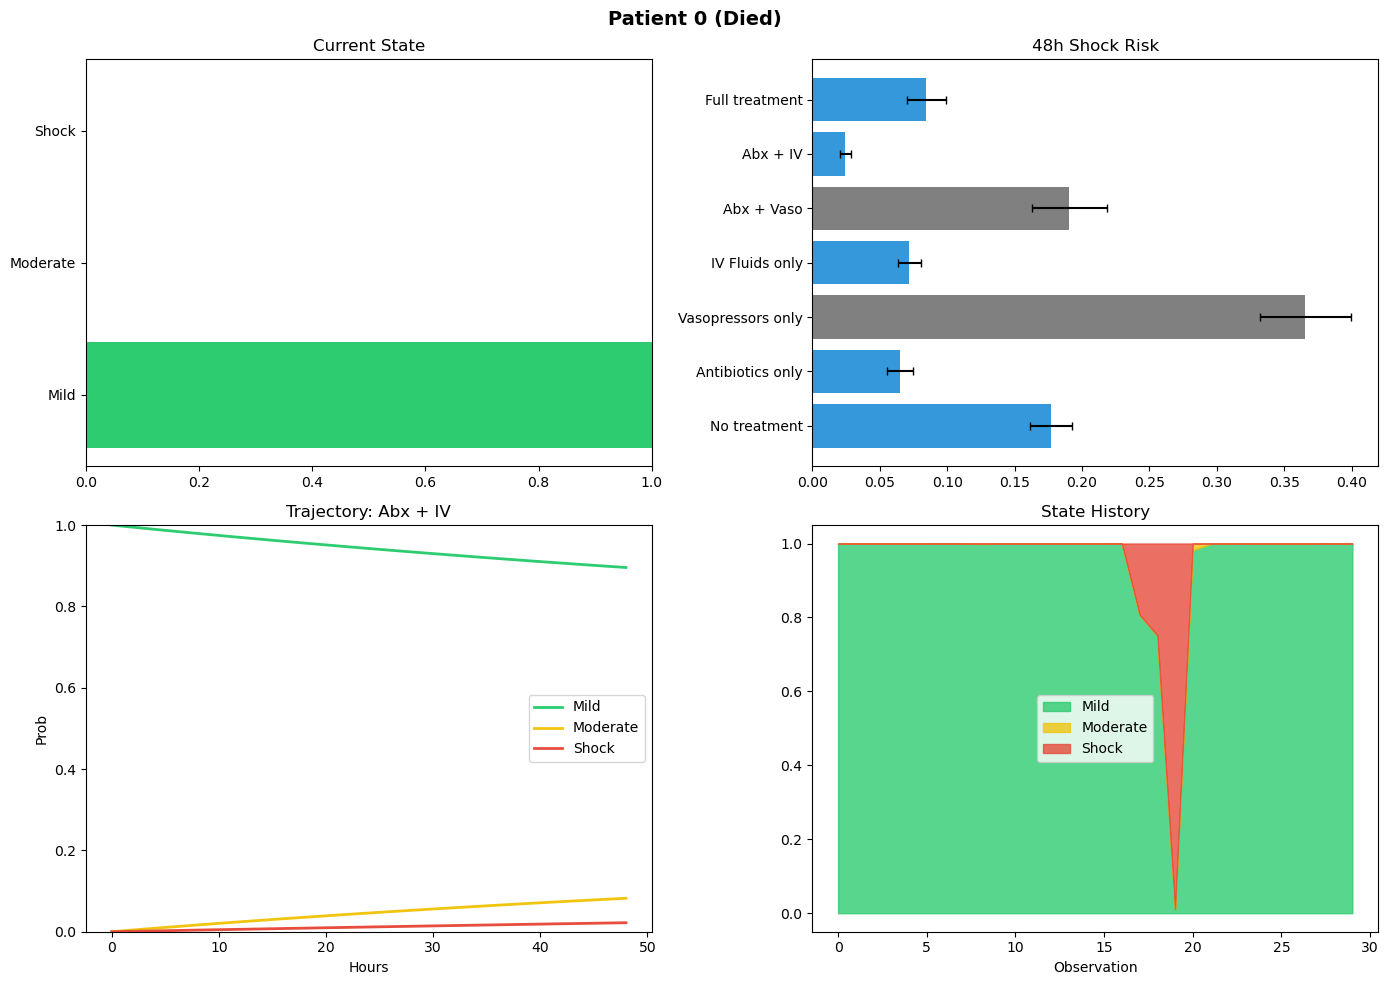

  Saved: patient_0_report.png

PATIENT 14 | obs=65 | Survived

  [Current State]
    Mild      :   0.0% 
    Moderate  : 100.0% █████████████████████████████
    Shock     :   0.0% 

  [State at Checkpoints]
         %        Mild    Moderate       Shock
       25%       0.0%     100.0%       0.0%
       49%       0.0%     100.0%       0.0%
       74%       0.0%     100.0%       0.0%
      100%       0.0%     100.0%       0.0%

  [48h Prediction (hourly)]
    Scenario                     Shock          95% CI
    --------------------------------------------------
    No treatment                14.1% [11.3%-17.0%]
    Antibiotics only             9.6% [7.0%-12.3%]
    Vasopressors only           27.7% [20.2%-35.3%] !!
    IV Fluids only               8.7% [6.7%-10.7%]
    Abx + Vaso                  19.4% [13.0%-25.8%] !!
    Abx + IV                     6.2% [4.3%-8.0%]
    Full treatment              12.9% [8.3%-17.4%]

  Recommendation: Abx + IV
    Shock reduction: 56.3% vs no trea

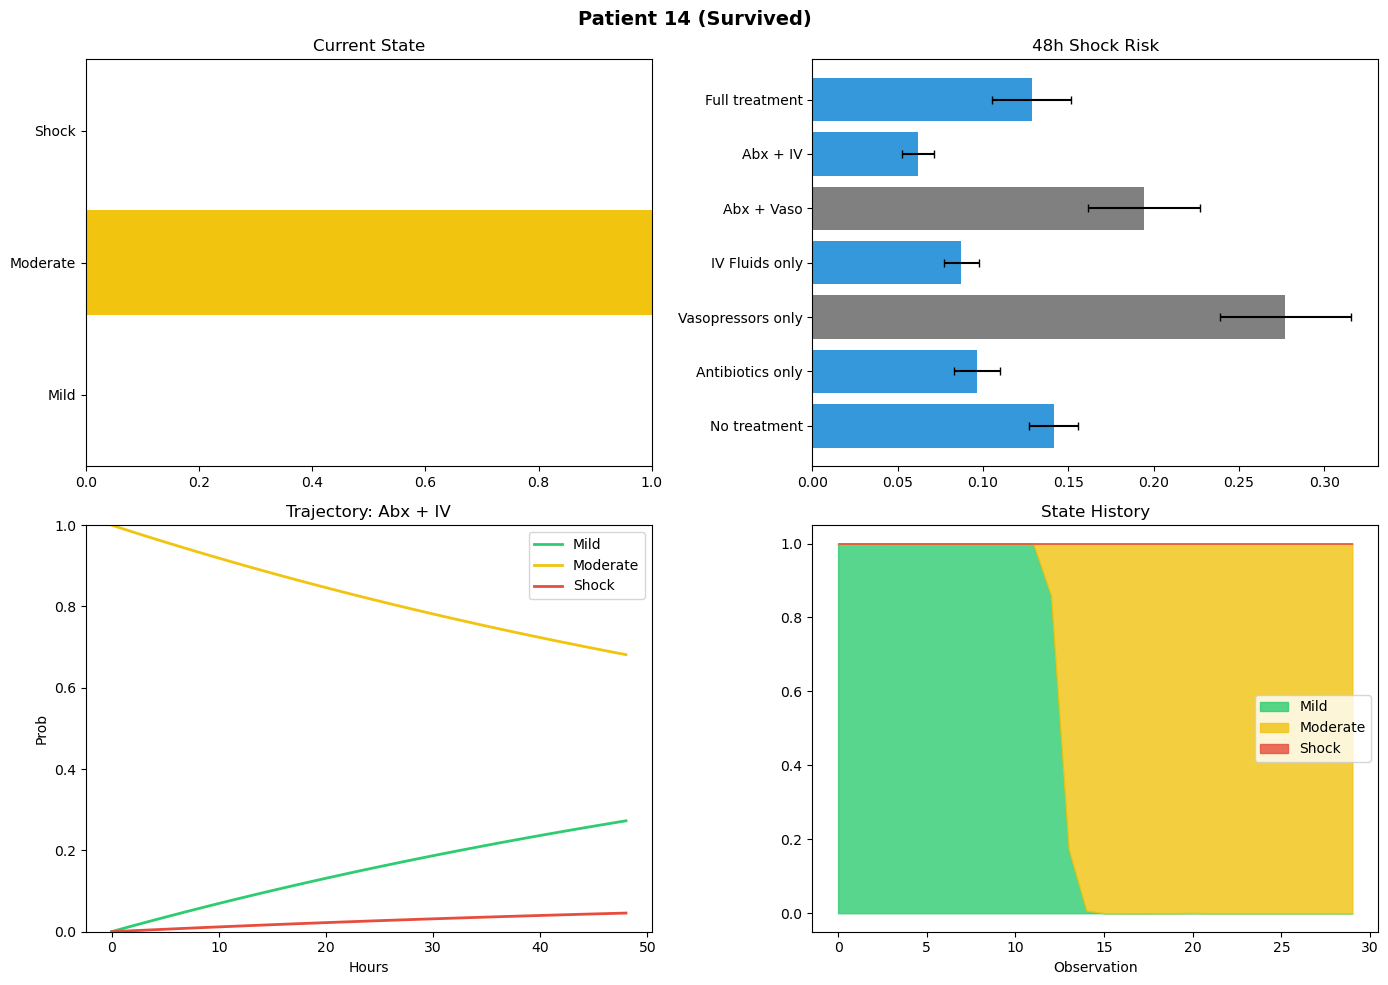

  Saved: patient_14_report.png

PATIENT 3 | obs=301 | Died

  [Current State]
    Mild      :   0.0% 
    Moderate  :   0.5% 
    Shock     :  99.5% █████████████████████████████

  [State at Checkpoints]
         %        Mild    Moderate       Shock
       25%       0.0%     100.0%       0.0%
       50%       0.0%     100.0%       0.0%
       75%       0.0%     100.0%       0.0%
      100%       0.0%       0.5%      99.5%

  [48h Prediction (hourly)]
    Scenario                     Shock          95% CI
    --------------------------------------------------
    No treatment                74.5% [68.2%-80.8%]
    Antibiotics only            79.8% [73.4%-86.2%]
    Vasopressors only           83.6% [77.9%-89.2%] !!
    IV Fluids only              69.1% [60.5%-77.6%]
    Abx + Vaso                  86.1% [80.7%-91.4%] !!
    Abx + IV                    75.2% [66.7%-83.6%]
    Full treatment              80.5% [72.3%-88.8%]

  Recommendation: IV Fluids only
    Shock reduction: 7.3% vs 

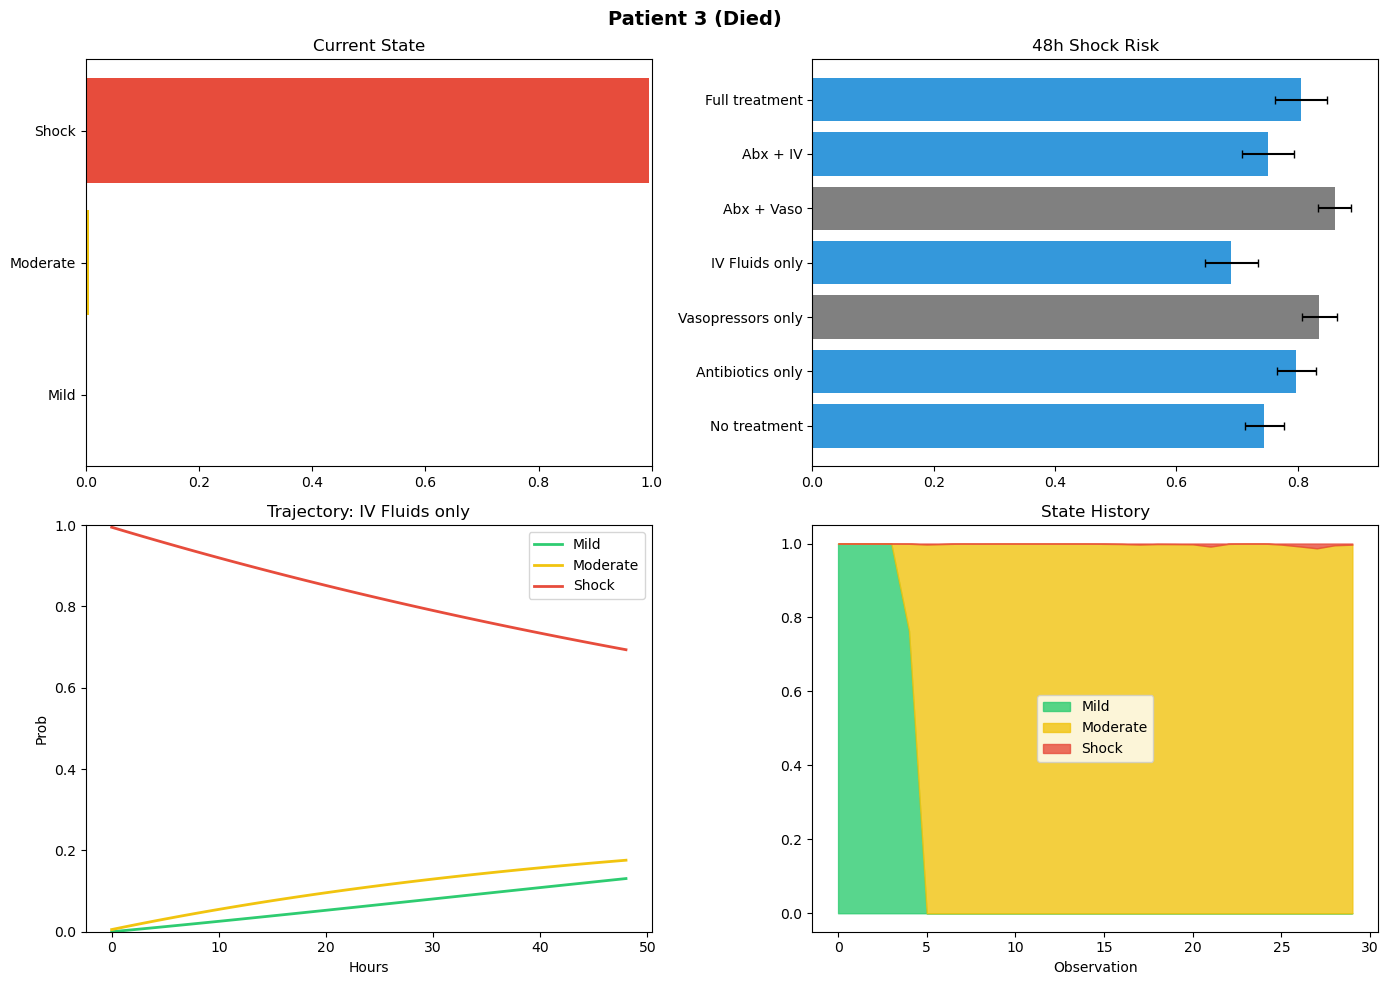

  Saved: patient_3_report.png


In [6]:
# Select one patient per dominant state
print("Selecting diverse patients...")
state_buckets = {k: [] for k in range(K)}
n_scan = min(300, len(obs_sequences))

for i in range(n_scan):
    bsof = (baseline_sofas[i] - bsof_mean) / bsof_std
    probs = predictor.infer_current_state(obs_sequences[i], int_sequences[i], bsof, si=0)
    dominant = np.argmax(probs)
    if len(state_buckets[dominant]) < 3:
        state_buckets[dominant].append(i)

EXAMPLE_PATIENTS = []
for k in range(K):
    if state_buckets[k]:
        EXAMPLE_PATIENTS.append(state_buckets[k][0])
        print(f"  {state_names[k]}: patient {state_buckets[k][0]}")
    else:
        print(f"  {state_names[k]}: none found")

if not EXAMPLE_PATIENTS:
    EXAMPLE_PATIENTS = [0, 10, 50]

for idx in EXAMPLE_PATIENTS:
    if idx < len(obs_sequences):
        generate_patient_report(
            idx, predictor, obs_sequences, int_sequences,
            baseline_sofas, bsof_mean, bsof_std, mortality_labels,
            state_names, FIG_DIR, n_hours=PREDICTION_HORIZON,
            n_posterior=N_POSTERIOR_SAMPLES)

## 📌 Clinical Summary: State → Treatment → Delay Analysis

For a given patient, produces a concise clinical decision report:

1. **Current State**: Probability distribution over Mild / Moderate / Shock
2. **Treatment Recommendations**: For each treatment, how much does 1-hour worsening probability decrease?
3. **1-Hour Delay Effect**: What happens if we wait 1 hour before treating?

This is the most actionable output — a physician can immediately understand:
what state is the patient in, which treatment helps most, and how urgently to act.

In [7]:
def clinical_summary(patient_idx, predictor, obs_sequences, int_sequences,
                      baseline_sofas, bsof_mean, bsof_std, mortality_labels,
                      state_names, n_posterior=20):
    """
    Clinical decision summary for one patient.
    
    1. Current state probabilities
    2. 48h treatment comparison (Shock risk for Mild/Moderate, Recovery chance for Shock)
    3. 1-hour delay penalty (48h outcome: treat NOW vs wait 1h then treat)
    """
    obs = obs_sequences[patient_idx]
    interv = int_sequences[patient_idx]
    bsof = (baseline_sofas[patient_idx] - bsof_mean) / bsof_std
    mort = mortality_labels[patient_idx]
    K = predictor.K
    N_HOURS = 48

    print(f"\n{'='*65}")
    print(f"  CLINICAL SUMMARY — Patient {patient_idx} ({'Died' if mort else 'Survived'})")
    print(f"{'='*65}")

    # =========================================================
    # 1. CURRENT STATE
    # =========================================================
    probs = predictor.infer_current_state(obs, interv, bsof, si=0)
    dominant = np.argmax(probs)
    is_shock = (dominant == K - 1)  # highest severity state

    print(f"\n  1. CURRENT STATE ASSESSMENT")
    print(f"  {'-'*40}")
    for k in range(K):
        marker = " ◀ MOST LIKELY" if k == dominant else ""
        bar = chr(9608) * int(probs[k] * 25)
        print(f"    {state_names[k]:10s}: {probs[k]:6.1%} {bar}{marker}")

    # =========================================================
    # 2. TREATMENT RECOMMENDATIONS (48h cumulative)
    # =========================================================
    if is_shock:
        metric_name = "48h RECOVERY probability (lower severity)"
        metric_label = "Recovery"
    else:
        metric_name = "48h SHOCK probability (worsening)"
        metric_label = "Shock Risk"

    print(f"\n  2. TREATMENT RECOMMENDATIONS ({metric_name})")
    print(f"  {'-'*40}")

    n_post = min(n_posterior, len(predictor.pi))
    indices = np.random.choice(len(predictor.pi), n_post, replace=False)

    treatments = {
        'No treatment':     [0, 0, 0],
        'Antibiotics':      [1, 0, 0],
        'IV Fluids':        [0, 0, 1],
        'Vasopressors':     [0, 1, 0],
        'Abx + IV':         [1, 0, 1],
        'Full treatment':   [1, 1, 1],
    }

    treat_results = {}
    for treat_name, treat_vec in treatments.items():
        samples = []
        for si in indices:
            traj = predictor.predict_trajectory(
                probs, treat_vec[:predictor.D_int], bsof, N_HOURS, si)
            final = traj[-1]  # 48h state distribution
            if is_shock:
                # Recovery = P(Mild) + P(Moderate) at 48h
                val = final[0] + final[1]  # sum of non-shock states
            else:
                # Shock risk = P(Shock) at 48h
                val = final[K - 1]
            samples.append(val)
        treat_results[treat_name] = {
            'mean': np.mean(samples),
            'std': np.std(samples),
            'ci_lo': np.percentile(samples, 2.5),
            'ci_hi': np.percentile(samples, 97.5),
        }

    no_tx = treat_results['No treatment']['mean']

    print(f"\n    Current state: {state_names[dominant]}")
    if is_shock:
        print(f"    Metric: Probability of recovering to Mild/Moderate in 48h")
        print(f"    (Higher = better)\n")
    else:
        print(f"    Metric: Probability of reaching Shock in 48h")
        print(f"    (Lower = better)\n")

    print(f"    {'Treatment':<20s} {metric_label:>12s} {'95% CI':>16s} {'vs No Tx':>10s}")
    print(f"    {'-'*60}")

    best_treat = None
    best_score = None

    for treat_name, res in treat_results.items():
        v = res['mean']
        ci = f"[{res['ci_lo']:.1%}-{res['ci_hi']:.1%}]"

        if treat_name == 'No treatment':
            diff_str = "baseline"
        else:
            if is_shock:
                # Higher recovery is better → show absolute increase
                diff = v - no_tx
                diff_str = f"{diff:+.1%}"
            else:
                # Lower shock is better → show reduction percentage
                if no_tx > 0:
                    diff = (no_tx - v) / no_tx * 100
                    diff_str = f"-{diff:.0f}%"
                else:
                    diff_str = "N/A"

        flag = " ⚠️" if "Vaso" in treat_name else ""
        print(f"    {treat_name:<20s} {v:>11.1%} {ci:>16s} {diff_str:>10s}{flag}")

        # Find best (exclude vasopressor-containing for confounding)
        if treat_name != 'No treatment' and 'Vaso' not in treat_name:
            if is_shock:
                # Best = highest recovery
                if best_score is None or v > best_score:
                    best_score = v
                    best_treat = treat_name
            else:
                # Best = lowest shock
                if best_score is None or v < best_score:
                    best_score = v
                    best_treat = treat_name

    if best_treat:
        if is_shock:
            print(f"\n    ★ Best treatment: {best_treat}")
            print(f"      Recovery chance: {best_score:.1%} (vs {no_tx:.1%} without treatment)")
        else:
            reduction = (no_tx - best_score) / no_tx * 100 if no_tx > 0 else 0
            print(f"\n    ★ Best treatment: {best_treat}")
            print(f"      48h Shock risk: {best_score:.1%} (vs {no_tx:.1%} = {reduction:.0f}% reduction)")

    # =========================================================
    # 3. ONE-HOUR DELAY PENALTY (48h outcome comparison)
    # =========================================================
    print(f"\n  3. ONE-HOUR DELAY PENALTY")
    print(f"  {'-'*40}")

    if best_treat:
        best_vec = treatments[best_treat]

        # Scenario A: Treat NOW for 48 hours
        now_samples = []
        # Scenario B: Wait 1 hour (no treatment), then treat for 47 hours
        delay_samples = []

        for si in indices:
            # A: Treat immediately for 48h
            traj_now = predictor.predict_trajectory(
                probs, best_vec[:predictor.D_int], bsof, N_HOURS, si)
            final_now = traj_now[-1]

            # B: 1h no treatment, then 47h with best treatment
            traj_wait = predictor.predict_trajectory(
                probs, [0, 0, 0], bsof, n_hours=1, si=si)
            probs_after_1h = traj_wait[1]
            traj_then = predictor.predict_trajectory(
                probs_after_1h, best_vec[:predictor.D_int], bsof, N_HOURS - 1, si)
            final_delay = traj_then[-1]

            if is_shock:
                now_samples.append(final_now[0] + final_now[1])
                delay_samples.append(final_delay[0] + final_delay[1])
            else:
                now_samples.append(final_now[K - 1])
                delay_samples.append(final_delay[K - 1])

        now_mean = np.mean(now_samples)
        delay_mean = np.mean(delay_samples)

        print(f"    Treatment: {best_treat}")
        print(f"")
        if is_shock:
            print(f"    Treat NOW  → 48h recovery chance: {now_mean:.1%}")
            print(f"    Wait 1 hour → 48h recovery chance: {delay_mean:.1%}")
            diff = now_mean - delay_mean
            if abs(diff) > 0.001:
                print(f"\n    ⏱️  1-hour delay costs {diff:.1%} recovery chance")
                print(f"       ({now_mean:.1%} → {delay_mean:.1%})")
            else:
                print(f"\n    Delay has minimal effect on recovery chance")
        else:
            print(f"    Treat NOW  → 48h Shock risk: {now_mean:.1%}")
            print(f"    Wait 1 hour → 48h Shock risk: {delay_mean:.1%}")
            diff = delay_mean - now_mean
            if abs(diff) > 0.001:
                pct = diff / now_mean * 100 if now_mean > 0 else 0
                print(f"\n    ⏱️  1-hour delay increases Shock risk by {diff:.1%} ({pct:.0f}% relative)")
                print(f"       ({now_mean:.1%} → {delay_mean:.1%})")
            else:
                print(f"\n    Delay has minimal effect on Shock risk")
    else:
        print(f"    No effective treatment identified.")

    print(f"\n{'='*65}")
    return probs, treat_results, best_treat

print("clinical_summary() v2 defined (48h cumulative, bidirectional)")

clinical_summary() v2 defined (48h cumulative, bidirectional)


In [8]:
# Run clinical summary + tipping point analysis for diverse patients
print("\n" + "=" * 65)
print("  RUNNING CLINICAL SUMMARIES")
print("=" * 65)

for idx in EXAMPLE_PATIENTS:
    if idx < len(obs_sequences):
        clinical_summary(
            idx, predictor, obs_sequences, int_sequences,
            baseline_sofas, bsof_mean, bsof_std, mortality_labels,
            state_names, n_posterior=N_POSTERIOR_SAMPLES
        )


  RUNNING CLINICAL SUMMARIES

  CLINICAL SUMMARY — Patient 0 (Died)

  1. CURRENT STATE ASSESSMENT
  ----------------------------------------
    Mild      : 100.0% ████████████████████████ ◀ MOST LIKELY
    Moderate  :   0.0% 
    Shock     :   0.0% 

  2. TREATMENT RECOMMENDATIONS (48h SHOCK probability (worsening))
  ----------------------------------------

    Current state: Mild
    Metric: Probability of reaching Shock in 48h
    (Lower = better)

    Treatment              Shock Risk           95% CI   vs No Tx
    ------------------------------------------------------------
    No treatment               17.7%    [15.2%-20.3%]   baseline
    Antibiotics                 6.6%      [5.2%-8.4%]       -63%
    IV Fluids                   7.2%      [5.7%-8.9%]       -60%
    Vasopressors               36.7%    [29.6%-43.7%]     --108% ⚠️
    Abx + IV                    2.4%      [1.8%-3.2%]       -86%
    Full treatment              8.5%     [5.7%-11.3%]       -52%

    ★ Best trea

## 📌 Tipping Point Analysis: Maximum Safe Delay

For each patient, sweeps delay time from 0 to 24 hours and finds the **critical point**
where 48h outcome starts to deteriorate sharply.

Method:
1. For each delay d = 0, 0.5, 1.0, ... 24.0 hours:
   - Simulate d hours of NO treatment
   - Then simulate (48 - d) hours of BEST treatment
   - Record the 48h outcome (Shock risk or Recovery chance)
2. Find the "elbow" where the curve's slope increases most rapidly
3. Plot the curve with the tipping point marked

In [9]:
def find_tipping_point(patient_idx, predictor, obs_sequences, int_sequences,
                       baseline_sofas, bsof_mean, bsof_std, mortality_labels,
                       state_names, fig_dir, n_posterior=20, max_delay_hours=24):
    """
    Sweep delay from 0 to max_delay_hours, find where 48h outcome degrades sharply.
    """
    obs = obs_sequences[patient_idx]
    interv = int_sequences[patient_idx]
    bsof = (baseline_sofas[patient_idx] - bsof_mean) / bsof_std
    mort = mortality_labels[patient_idx]
    K = predictor.K
    N_TOTAL = 48  # total prediction horizon

    # Infer current state
    probs = predictor.infer_current_state(obs, interv, bsof, si=0)
    dominant = np.argmax(probs)
    is_shock = (dominant == K - 1)

    # Determine best treatment (from clinical_summary logic)
    treatments = {
        'Antibiotics': [1, 0, 0],
        'IV Fluids':   [0, 0, 1],
        'Abx + IV':    [1, 0, 1],
    }

    n_post = min(n_posterior, len(predictor.pi))
    indices = np.random.choice(len(predictor.pi), n_post, replace=False)

    # Find best treatment
    best_treat = None
    best_score = None
    for treat_name, treat_vec in treatments.items():
        samples = []
        for si in indices:
            traj = predictor.predict_trajectory(probs, treat_vec[:predictor.D_int], bsof, N_TOTAL, si)
            final = traj[-1]
            if is_shock:
                samples.append(final[0] + final[1])  # recovery
            else:
                samples.append(final[K-1])  # shock risk
        mean_val = np.mean(samples)
        if is_shock:
            if best_score is None or mean_val > best_score:
                best_score = mean_val
                best_treat = treat_name
        else:
            if best_score is None or mean_val < best_score:
                best_score = mean_val
                best_treat = treat_name

    best_vec = treatments[best_treat]

    # Sweep delay from 0 to max_delay_hours in 30-min steps
    delay_steps = np.arange(0, max_delay_hours + 0.5, 0.5)
    outcome_mean = []
    outcome_lo = []
    outcome_hi = []

    for delay_h in delay_steps:
        delay_int = max(1, int(round(delay_h)))  # at least 1 step
        treat_int = max(1, N_TOTAL - delay_int)

        samples = []
        for si in indices:
            if delay_h == 0:
                # No delay: treat immediately for 48h
                traj = predictor.predict_trajectory(probs, best_vec[:predictor.D_int], bsof, N_TOTAL, si)
            else:
                # Wait delay_int hours (no treatment), then treat for remaining
                traj_wait = predictor.predict_trajectory(probs, [0,0,0], bsof, delay_int, si)
                probs_delayed = traj_wait[-1]
                traj_treat = predictor.predict_trajectory(probs_delayed, best_vec[:predictor.D_int], bsof, treat_int, si)
                traj = traj_treat  # use the treated trajectory

            final = traj[-1]
            if is_shock:
                samples.append(final[0] + final[1])
            else:
                samples.append(final[K-1])

        outcome_mean.append(np.mean(samples))
        outcome_lo.append(np.percentile(samples, 10))
        outcome_hi.append(np.percentile(samples, 90))

    outcome_mean = np.array(outcome_mean)
    outcome_lo = np.array(outcome_lo)
    outcome_hi = np.array(outcome_hi)

    # Find tipping point: where second derivative (acceleration) is maximum
    # Use first derivative (rate of change)
    if len(outcome_mean) > 2:
        first_deriv = np.diff(outcome_mean)
        second_deriv = np.diff(first_deriv)

        if is_shock:
            # For shock patients, recovery decreases — find where it drops fastest
            # (most negative first derivative acceleration)
            tp_idx = np.argmin(second_deriv) + 1  # +1 for offset
        else:
            # For non-shock, shock risk increases — find where it accelerates most
            tp_idx = np.argmax(second_deriv) + 1

        tipping_hours = delay_steps[tp_idx]
        tipping_value = outcome_mean[tp_idx]
    else:
        tipping_hours = 0
        tipping_value = outcome_mean[0]

    # Also find threshold-based tipping point
    baseline_val = outcome_mean[0]  # outcome with 0 delay
    if is_shock:
        # Recovery: find when recovery drops below 90% of baseline
        threshold = baseline_val * 0.9
        threshold_idx = np.where(outcome_mean < threshold)[0]
    else:
        # Shock risk: find when risk exceeds 150% of baseline (50% worse)
        threshold = baseline_val * 1.5
        threshold_idx = np.where(outcome_mean > threshold)[0]

    if len(threshold_idx) > 0:
        threshold_hours = delay_steps[threshold_idx[0]]
        threshold_value = outcome_mean[threshold_idx[0]]
    else:
        threshold_hours = max_delay_hours
        threshold_value = outcome_mean[-1]

    # Print results
    print(f"\n{'='*65}")
    print(f"  TIPPING POINT — Patient {patient_idx} ({state_names[dominant]})")
    print(f"{'='*65}")
    print(f"  Best treatment: {best_treat}")
    print(f"")

    if is_shock:
        print(f"  48h Recovery Chance by Delay:")
    else:
        print(f"  48h Shock Risk by Delay:")

    print(f"")
    print(f"    {'Delay':>8s}  {'Outcome':>10s}  {'Change':>10s}")
    print(f"    {'-'*32}")

    # Print key delay points
    key_points = [0, 1, 2, 3, 4, 6, 8, 12, 18, 24]
    for h in key_points:
        if h > max_delay_hours:
            break
        idx_h = int(h * 2)  # 0.5h steps
        if idx_h < len(outcome_mean):
            val = outcome_mean[idx_h]
            if h == 0:
                change = "baseline"
            else:
                diff = val - outcome_mean[0]
                change = f"{diff:+.1%}"
            print(f"    {h:>5.0f}h    {val:>9.1%}  {change:>10s}")

    print(f"")
    print(f"  ⚡ Acceleration tipping point: ~{tipping_hours:.1f} hours")
    print(f"     (curve bends most sharply here)")

    if is_shock:
        print(f"  ⚠️  Safe delay limit: ~{threshold_hours:.1f} hours")
        print(f"     (recovery drops below 90% of immediate treatment)")
        print(f"     Immediate: {baseline_val:.1%} → After {threshold_hours:.0f}h delay: {threshold_value:.1%}")
    else:
        print(f"  ⚠️  Safe delay limit: ~{threshold_hours:.1f} hours")
        print(f"     (shock risk exceeds 150% of immediate treatment)")
        print(f"     Immediate: {baseline_val:.1%} → After {threshold_hours:.0f}h delay: {threshold_value:.1%}")

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    ax.plot(delay_steps, outcome_mean * 100, 'b-', linewidth=2, label='Mean')
    ax.fill_between(delay_steps, outcome_lo * 100, outcome_hi * 100, alpha=0.2, color='blue', label='80% CI')

    # Mark tipping point
    ax.axvline(x=tipping_hours, color='red', linestyle='--', alpha=0.7, label=f'Acceleration point ({tipping_hours:.1f}h)')
    ax.axvline(x=threshold_hours, color='orange', linestyle='--', alpha=0.7, label=f'Safe limit ({threshold_hours:.1f}h)')

    # Mark immediate treatment level
    ax.axhline(y=outcome_mean[0] * 100, color='green', linestyle=':', alpha=0.5, label=f'Immediate treatment ({outcome_mean[0]:.1%})')

    if is_shock:
        ax.set_ylabel('48h Recovery Chance (%)', fontsize=12)
        ax.set_title(f'Patient {patient_idx} ({state_names[dominant]}, {"Died" if mort else "Survived"}): '
                     f'Recovery vs Treatment Delay — {best_treat}', fontsize=13)
    else:
        ax.set_ylabel('48h Shock Risk (%)', fontsize=12)
        ax.set_title(f'Patient {patient_idx} ({state_names[dominant]}, {"Died" if mort else "Survived"}): '
                     f'Shock Risk vs Treatment Delay — {best_treat}', fontsize=13)

    ax.set_xlabel('Treatment Delay (hours)', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, max_delay_hours)

    plt.tight_layout()
    plt.savefig(f"{fig_dir}/patient_{patient_idx}_tipping_point.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: patient_{patient_idx}_tipping_point.png")
    print(f"{'='*65}")

    return delay_steps, outcome_mean, tipping_hours, threshold_hours

print("find_tipping_point() defined")

find_tipping_point() defined



  TIPPING POINT ANALYSIS

  TIPPING POINT — Patient 0 (Mild)
  Best treatment: Abx + IV

  48h Shock Risk by Delay:

       Delay     Outcome      Change
    --------------------------------
        0h         2.4%    baseline
        1h         2.8%       +0.4%
        2h         3.2%       +0.7%
        3h         3.5%       +1.1%
        4h         3.9%       +1.4%
        6h         4.6%       +2.1%
        8h         5.2%       +2.8%
       12h         6.6%       +4.2%
       18h         8.6%       +6.1%
       24h        10.5%       +8.1%

  ⚡ Acceleration tipping point: ~1.0 hours
     (curve bends most sharply here)
  ⚠️  Safe delay limit: ~3.5 hours
     (shock risk exceeds 150% of immediate treatment)
     Immediate: 2.4% → After 4h delay: 3.9%


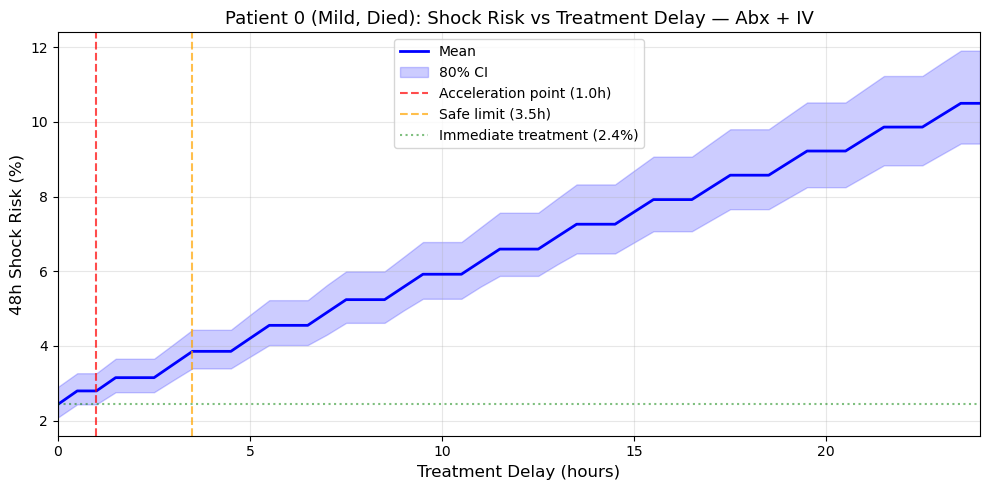

  Saved: patient_0_tipping_point.png

  TIPPING POINT — Patient 14 (Moderate)
  Best treatment: Abx + IV

  48h Shock Risk by Delay:

       Delay     Outcome      Change
    --------------------------------
        0h         6.2%    baseline
        1h         6.3%       +0.1%
        2h         6.4%       +0.3%
        3h         6.5%       +0.4%
        4h         6.7%       +0.5%
        6h         6.9%       +0.8%
        8h         7.2%       +1.1%
       12h         7.8%       +1.6%
       18h         8.7%       +2.6%
       24h         9.7%       +3.5%

  ⚡ Acceleration tipping point: ~22.5 hours
     (curve bends most sharply here)
  ⚠️  Safe delay limit: ~21.5 hours
     (shock risk exceeds 150% of immediate treatment)
     Immediate: 6.2% → After 22h delay: 9.4%


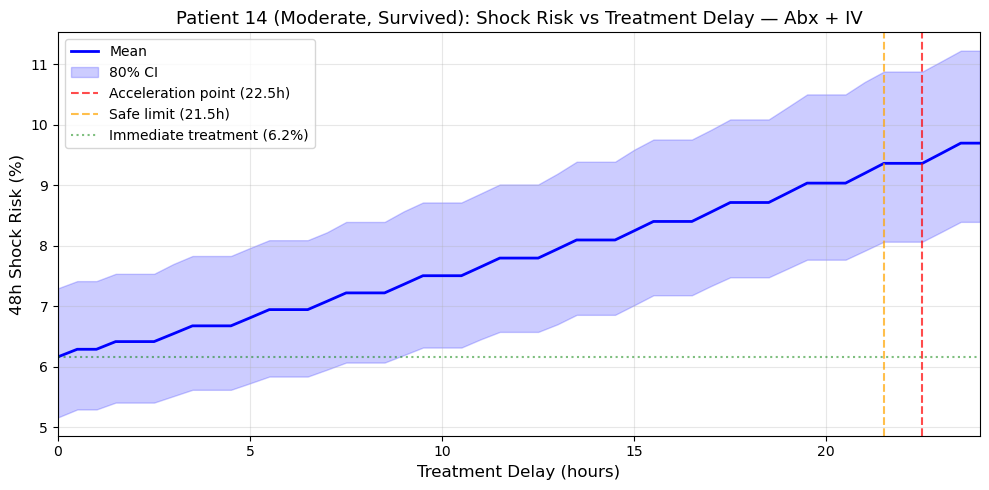

  Saved: patient_14_tipping_point.png

  TIPPING POINT — Patient 3 (Shock)
  Best treatment: IV Fluids

  48h Recovery Chance by Delay:

       Delay     Outcome      Change
    --------------------------------
        0h        31.0%    baseline
        1h        30.9%       -0.1%
        2h        30.8%       -0.2%
        3h        30.8%       -0.2%
        4h        30.7%       -0.3%
        6h        30.5%       -0.5%
        8h        30.3%       -0.7%
       12h        30.0%       -1.0%
       18h        29.4%       -1.6%
       24h        28.7%       -2.3%

  ⚡ Acceleration tipping point: ~22.5 hours
     (curve bends most sharply here)
  ⚠️  Safe delay limit: ~24.0 hours
     (recovery drops below 90% of immediate treatment)
     Immediate: 31.0% → After 24h delay: 28.7%


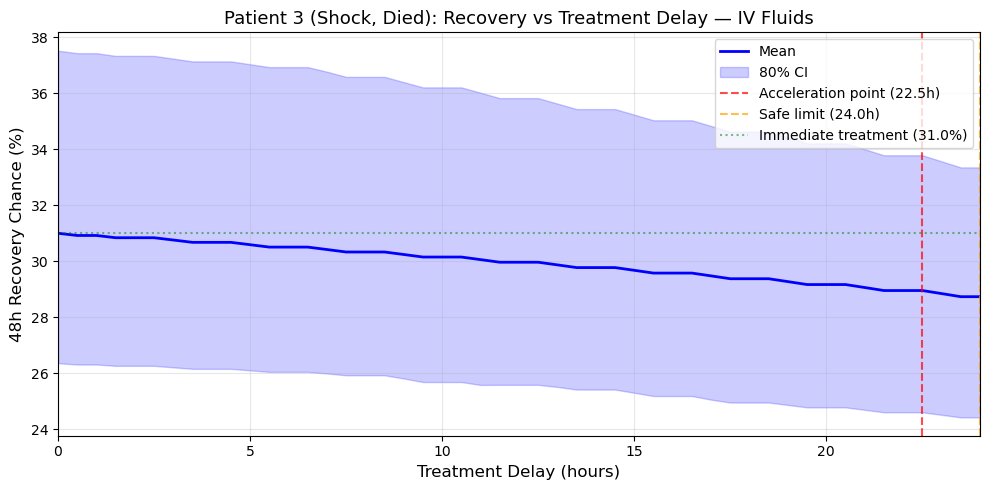

  Saved: patient_3_tipping_point.png


In [10]:
# Run tipping point analysis for diverse patients
print("\n" + "=" * 65)
print("  TIPPING POINT ANALYSIS")
print("=" * 65)

for idx in EXAMPLE_PATIENTS:
    if idx < len(obs_sequences):
        find_tipping_point(
            idx, predictor, obs_sequences, int_sequences,
            baseline_sofas, bsof_mean, bsof_std, mortality_labels,
            state_names, FIG_DIR, n_posterior=N_POSTERIOR_SAMPLES,
            max_delay_hours=24
        )

## 📌 Batch Risk Stratification

Classify all patients (up to 500) into risk groups based on their inferred shock probability.

**Threshold**: Shock probability > 30% → "High Risk"

The key metric is the **mortality ratio**: how many times more likely are high-risk patients
to die compared to low-risk patients? A ratio > 5x indicates the model captures meaningful
clinical risk differentiation.

In [11]:
print("\n" + "=" * 60)
print("BATCH RISK STRATIFICATION")
print("=" * 60)

risk_results = []
n_eval = min(500, len(obs_sequences))

for i in range(n_eval):
    bsof = (baseline_sofas[i] - bsof_mean) / bsof_std
    probs = predictor.infer_current_state(obs_sequences[i], int_sequences[i], bsof, si=0)
    shock_prob = probs[-1]
    moderate_prob = probs[-2] if K > 2 else 0
    risk_results.append({
        'patient_idx': i,
        'stay_id': stay_ids[i] if i < len(stay_ids) else -1,
        'mortality': mortality_labels[i],
        'shock_prob': shock_prob,
        'high_risk': 1 if shock_prob > 0.3 else 0,
    })

risk_df = pd.DataFrame(risk_results)
print(f"  Evaluated: {n_eval}")
print(f"  High risk (Shock > 30%): {risk_df['high_risk'].mean():.1%}")
hr = risk_df[risk_df['high_risk']==1]
lr = risk_df[risk_df['high_risk']==0]
if len(hr) > 0:
    print(f"  High-risk mortality: {hr['mortality'].mean():.1%}")
if len(lr) > 0:
    print(f"  Low-risk mortality:  {lr['mortality'].mean():.1%}")
if len(hr) > 0 and len(lr) > 0 and lr['mortality'].mean() > 0:
    print(f"  Mortality ratio: {hr['mortality'].mean()/lr['mortality'].mean():.1f}x")
risk_df.to_csv(f"{RESULTS_DIR}/risk_stratification_v5.csv", index=False)


BATCH RISK STRATIFICATION
  Evaluated: 500
  High risk (Shock > 30%): 22.2%
  High-risk mortality: 53.2%
  Low-risk mortality:  8.2%
  Mortality ratio: 6.5x


## 📌 Final Summary

In [12]:
print("\n" + "=" * 60)
print("CLINICAL DSS v5 COMPLETE")
print("=" * 60)
print(f"""
  Model: Bayesian HMM with {K} states (free emission)
  States: {', '.join(state_names)} (ordered post-hoc by SOFA mean)
  State order mapping: {state_order.tolist()}
  Treatments: {', '.join(int_features)}

  v5 Features:
    1. Free emission — states from all 14 features, not just SOFA
    2. Treatment x SOFA interaction (patient-specific effects)
    3. Time-aware transitions (delta_t in transition model)
    4. Hourly counterfactual (real 1-hour steps, properly scaled)
    5. Diverse patient examples (one per state)
    6. Checkpoint state history (25/50/75/100%)

  Output:
    {FIG_DIR}/patient_*_report.png
    {RESULTS_DIR}/risk_stratification_v5.csv
""")


CLINICAL DSS v5 COMPLETE

  Model: Bayesian HMM with 3 states (free emission)
  States: Mild, Moderate, Shock (ordered post-hoc by SOFA mean)
  State order mapping: [0, 1, 2]
  Treatments: on_antibiotics, on_vasopressors, on_iv_fluids

  v5 Features:
    1. Free emission — states from all 14 features, not just SOFA
    2. Treatment x SOFA interaction (patient-specific effects)
    3. Time-aware transitions (delta_t in transition model)
    4. Hourly counterfactual (real 1-hour steps, properly scaled)
    5. Diverse patient examples (one per state)
    6. Checkpoint state history (25/50/75/100%)

  Output:
    /Users/hoon/Documents/10_Classes/12_Bayesian Machine Learning with Generative AI Applications/10_Final_Project/04_Model_Results/Prediction_Figures/patient_*_report.png
    /Users/hoon/Documents/10_Classes/12_Bayesian Machine Learning with Generative AI Applications/10_Final_Project/04_Model_Results/risk_stratification_v5.csv

